# Demo: Neural Activity During Brain-Controlled Movements

This demo loads a single BMI session (Monkey Bohr, 115 units) and visualizes
peri-event neural activity aligned to movement onset.

In [1]:
import os
import numpy as np
import pandas as pd
import pynapple as nap
import matplotlib.pyplot as plt

## Load NWB and extract trials

In [2]:
ts_data = nap.load_file(os.path.join('demo_data', 'demo_bmi.nwb'))

units = ts_data['units']
markers = ts_data['BehaviorMarkers']
pos = ts_data['pos']
training_flag = ts_data['training flag']

# Parse trial boundaries
marker_data = markers.d[:]
if marker_data[0] < 0:
    marker_data = marker_data + 65280

trial_start_idx = np.sort(np.where(marker_data == 24)[0])
trial_end_idx = np.sort(np.where(marker_data == 5)[0][:len(trial_start_idx)])

trial_marker = [markers[i:j+1] for i, j in zip(trial_start_idx, trial_end_idx)]
trial_flag = [training_flag.get(m.t[0], m.t[-1]) for m in trial_marker]
trial_pos = [
    pos.get(m.t[0], m.t[-1]) if sum(f.d[:]) == 0 else None
    for m, f in zip(trial_marker, trial_flag)
]

# Movement onset: position norm > 1.5
def get_mo(p):
    norms = np.linalg.norm(p.to_numpy(), axis=1)
    idx = np.where(norms > 1.5)[0]
    return float(p.t[idx[0]]) if len(idx) > 0 else None

trial_mo = [get_mo(p) if p is not None else None for p in trial_pos]

trial_df = pd.DataFrame({'markers': trial_marker, 'pos': trial_pos, 'mo_time': trial_mo})
trial_df = trial_df.dropna()
trial_df = trial_df[trial_df['markers'].apply(lambda x: 20 in x.d[:])]

print(f"Units: {len(units)}, Successful trials: {len(trial_df)}")

Units: 115, Successful trials: 321


## Compute peri-event firing rates

In [3]:
mo_ts = nap.Ts(t=trial_df['mo_time'].values, time_units='s')
window = nap.IntervalSet(start=-0.5, end=0.5, time_units='s')

peth = nap.compute_perievent(units, mo_ts, minmax=(-1, 1), time_unit='s')
unit_ids = np.array(list(peth.keys()))

# Bin and smooth
smoothed = [
    peth[uid].count(0.02).smooth(std=0.05, size_factor=5, time_units='s', norm=True)
    .restrict(window) / 0.02
    for uid in unit_ids
]
bin_time = smoothed[0].t

# Mean firing rate per unit (averaged across trials)
mean_fr = np.array([s.as_array().mean(axis=1) for s in smoothed])  # (n_units, n_time)

print(f"Firing rate matrix: {mean_fr.shape[0]} units x {mean_fr.shape[1]} time bins")

Firing rate matrix: 115 units x 50 time bins


## Plot: firing rate heatmap

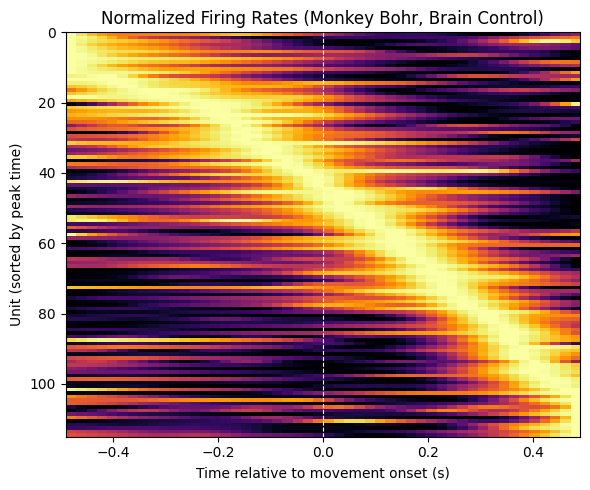

In [4]:
# Normalize each unit to [0, 1]
fr_norm = mean_fr.copy()
for i in range(fr_norm.shape[0]):
    mn, mx = fr_norm[i].min(), fr_norm[i].max()
    if mx > mn:
        fr_norm[i] = (fr_norm[i] - mn) / (mx - mn)

# Sort by peak time
peak_idx = np.argmax(fr_norm, axis=1)
sort_order = np.argsort(peak_idx)

fig, ax = plt.subplots(figsize=(6, 5))
ax.imshow(fr_norm[sort_order], aspect='auto', cmap='inferno',
          extent=[bin_time[0], bin_time[-1], fr_norm.shape[0], 0])
ax.axvline(0, color='white', linestyle='--', linewidth=0.8)
ax.set_xlabel('Time relative to movement onset (s)')
ax.set_ylabel('Unit (sorted by peak time)')
ax.set_title('Normalized Firing Rates (Monkey Bohr, Brain Control)')
plt.tight_layout()
plt.show()